# 📊 Predicción de Series Temporales con MLP, LSTM y BiLSTM
### Dataset: Bitcoin (BTC/USDT)
Este cuadernillo implementa modelos de redes neuronales para predicción de precios.


## 🧠 Modelos utilizados
- **MLP**: Red neuronal densa sin memoria temporal.
- **LSTM**: Red recurrente que captura dependencias temporales.
- **BiLSTM**: LSTM bidireccional que analiza pasado y futuro.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

## 📥 Carga de datos

In [2]:
df = pd.read_csv("btc_15m_data_2018_to_2025.csv")
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.sort_values('Open time')
df = df[['Open','High','Low','Close','Volume']].dropna()
df.head()

,Open,High,Low,Close,Volume
0,13715.65,13715.65,13400.01,13556.15,123.616013
1,13533.75,13550.87,13402.00,13521.12,98.136430
2,13500.00,13545.37,13450.00,13470.41,79.904037
3,13494.65,13690.87,13450.00,13529.01,141.699719
4,13528.99,13571.74,13402.28,13445.63,72.537533


## 🔄 Normalización

In [3]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df)

## 🔁 Creación de ventanas

In [4]:
def create_dataset(data, window_size=10):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size][3])
    return np.array(X), np.array(y)

window_size = 10
X, y = create_dataset(data_scaled, window_size)

## ✂️ División de datos

In [5]:
split = int(0.8*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## 🧱 Modelo MLP

In [6]:
X_train_mlp = X_train.reshape(X_train.shape[0], -1)
X_test_mlp = X_test.reshape(X_test.shape[0], -1)

mlp = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_mlp.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp.compile(optimizer='adam', loss='mse')
mlp.fit(X_train_mlp, y_train, epochs=20, batch_size=32, validation_split=0.1)

c:\Users\LENOVO LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 3.5105e-05 - val_loss: 8.4531e-06
Epoch 2/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 1.1700e-05 - val_loss: 9.6105e-06
Epoch 3/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1.0017e-05 - val_loss: 2.4919e-05
Epoch 4/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 9.0492e-06 - val_loss: 7.3063e-06
Epoch 5/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 7.7672e-06 - val_loss: 3.4038e-06
Epoch 6/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 7.0146e-06 - val_loss: 5.0828e-06
Epoch 7/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 6.1986e-06 - val_loss: 2.7139e-06
Epoch 8/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 7.0249e-06 - val_loss: 4.5589e-06
Epoch 9/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 6.6208e-06 - val_loss: 2.6797e-06
Epoch 10/20
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 5.4614e-06 - val_loss: 3.5482e-06
Epoch 11/20
6460/6460 ━━━━━━━━━━━━━

## 🔁 Modelo LSTM Mejorado

In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(window_size, X.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=[early_stop])

c:\Users\LENOVO LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 118s 17ms/step - loss: 5.8299e-05 - val_loss: 3.8757e-05
Epoch 2/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 109s 17ms/step - loss: 3.0441e-05 - val_loss: 1.6807e-05
Epoch 3/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 112s 17ms/step - loss: 2.4910e-05 - val_loss: 3.7255e-04
Epoch 4/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 116s 18ms/step - loss: 2.2367e-05 - val_loss: 5.7470e-05
Epoch 5/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 131s 20ms/step - loss: 2.0414e-05 - val_loss: 9.0426e-05
Epoch 6/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 119s 18ms/step - loss: 1.8954e-05 - val_loss: 8.6313e-05
Epoch 7/50
6460/6460 ━━━━━━━━━━━━━━━━━━━━ 178s 28ms/step - loss: 1.7670e-05 - val_loss: 1.7817e-04


## 🔮 Predicciones

In [12]:
y_pred_mlp = mlp.predict(X_test_mlp)
y_pred_lstm = lstm.predict(X_test)

1795/1795 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step


## 📊 Evaluación

In [13]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(nombre, 'MSE:', mse, 'RMSE:', rmse, 'MAE:', mae)

evaluar(y_test, y_pred_mlp, 'MLP')
evaluar(y_test, y_pred_lstm, 'LSTM')

MLP MSE: 1.19386892664504e-05 RMSE: 0.003455240840585559 MAE: 0.0028610689285038745
LSTM MSE: 0.034221188500125066 RMSE: 0.18498969836216575 MAE: 0.1524517377420016


## 📈 Gráficas

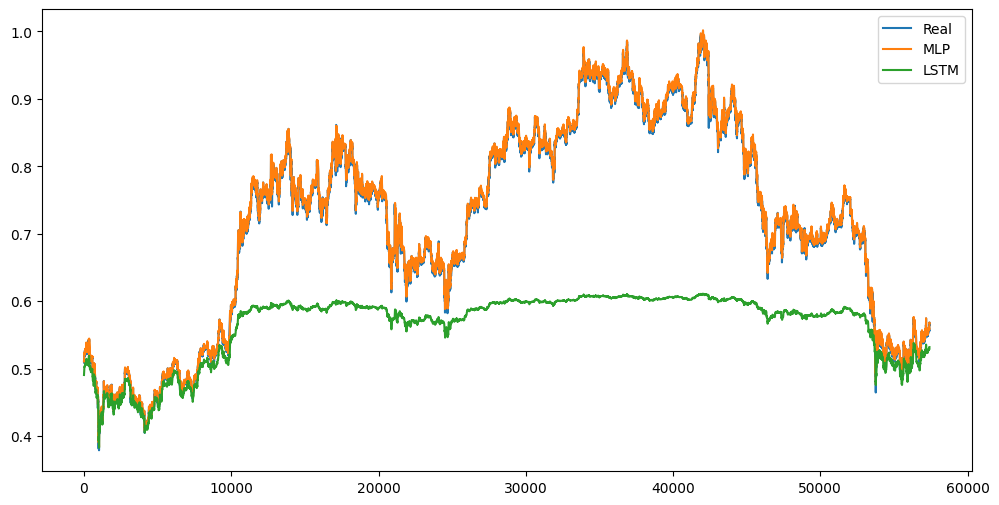

In [14]:
plt.figure(figsize=(12,6))
plt.plot(y_test)
plt.plot(y_pred_mlp)
plt.plot(y_pred_lstm)
plt.legend(['Real','MLP','LSTM'])
plt.show()